# Example: Train a Vision Transformer (ViT) for image classification

This example guides you through developing and training a Vision Transformer (ViT) model using Flax NNX. The architecture is based on ["An Image is Worth 16x16 Words"](https://arxiv.org/abs/2010.11929) by Dosovitskiy et al. (2020). This example shows how to define a ViT model using Flax NNX, load the pretrained ImageNet weights from the ViT transformer weights of `google/vit-base-patch16-224` on HuggingFace, which was pretrained on ImageNet-21k, and then fine-tune on the [Food 101](https://huggingface.co/datasets/ethz/food101) dataset for image classification. We will also check the results for consistency with the reference model.

This example is adapted from the JAX AI Stack tutorial [Train a Vision Transformer (ViT) for image classification with JAX](https://docs.jaxstack.ai/en/latest/JAX_Vision_transformer.html). The original JAX-based implementation of the ViT model can be found in the [google-research/vision_transformer](https://github.com/google-research/vision_transformer/) GitHub repository.

## Setup

This example uses HuggingFace [Datasets](https://huggingface.co/docs/datasets/) for dataset loading, [TorchVision](https://pytorch.org/vision) for image augmentations, [grain](https://github.com/google/grain/) for efficient data loading, [tqdm](https://tqdm.github.io/) for a progress bar to monitor training, and [matplotlib](https://matplotlib.org/stable/) for visualization purposes. These libraries can be installed with `!pip install -U datasets grain torchvision tqdm matplotlib`.

Start by importing JAX, JAX NumPy, Flax NNX, and Optax:

In [1]:
import jax
import jax.numpy as jnp
from flax import nnx
import optax

## The ViT architecture

A Vision Transformer (ViT) treats images as sequences of patches and leverages the attention mechanism from transformers. The architecture consists of the following key components:

- **Patch and position embedding:** Breaking down an image into fixed-size patches and embedding each patch into a vector representation. Positional embeddings are added to encode the position of each patch within the original image, which aids with spatial information.
- **Transformer encoder:** A stack of transformer encoder blocks processes the input embedded patches. Each block consists of:
  - **Multi-Head (Self-)Attention:** This allows the model to weigh the importance of different patches relative to each other, capturing relationships within the image.
  - **Feed-forward network:** Processes each patch independently, allowing a for non-linear transformations.
  - **Layer normatlization and residual connections:** Stabilize training and improve gradient flow in the network.
- **Classification head:** The output of the transformer encoder is fed into a linear layer and then a softmax function, resulting in class probabilities for prediction.

![ViT-architecture](https://github.com/google-research/vision_transformer/raw/main/vit_figure.png)


### Defining the model with Flax NNX

In [2]:
from dataclasses import dataclass

from jax.sharding import PartitionSpec as P


@dataclass(slots=True, frozen=True)
class ShardingConfig:

    attn_qkvo_weight_ndh: P | None = None  # sharding for Q, K, V, Out weights
    mlp_weight_df: P | None = None
    mlp_weight_fd: P | None = None
    act_btd: P | None = None  # sharding of the activation (B, T, D)
    act_btf: P | None = None
    act_btnh: P | None = None
    act_bc: P | None = None  # sharding of the final logits

    fsdp_axis_name: str = "fsdp"

    @staticmethod
    def no_sharding():
        return ShardingConfig()

    @staticmethod
    def fsdp_sharding(fsdp_axis_name: str = "fsdp"):
        fsdp = fsdp_axis_name
        return ShardingConfig(
            attn_qkvo_weight_ndh=P(None, fsdp, None),
            mlp_weight_df=P(fsdp, None),
            mlp_weight_fd=P(None, fsdp),
            act_btd=P(fsdp, None, None),
            act_btf=P(fsdp, None, None),
            act_btnh=P(fsdp, None, None, None),
            act_bc=P(fsdp, None),
            fsdp_axis_name=fsdp_axis_name,
        )


@dataclass(slots=True, frozen=True)
class ModelConfig:
    num_classes: int = 1000
    in_channels: int = 3
    img_size: int = 224
    patch_size: int = 16
    num_layers: int = 12
    num_heads: int = 12
    mlp_dim: int = 3072
    hidden_size: int = 768
    dropout_rate: float = 0.1
    sharding: ShardingConfig = ShardingConfig.no_sharding()


class VisionTransformer(nnx.Module):
    def __init__(
        self,
        config: ModelConfig,
        *,
        rngs: nnx.Rngs,
    ):
        n_patches = (config.img_size // config.patch_size) ** 2
        self.patch_embeddings = nnx.Conv(
            config.in_channels,
            config.hidden_size,
            kernel_size=(config.patch_size, config.patch_size),
            strides=(config.patch_size, config.patch_size),
            padding="VALID",
            use_bias=True,
            rngs=rngs,
        )

        initializer = jax.nn.initializers.truncated_normal(stddev=0.02)
        self.position_embeddings = nnx.Param(
            initializer(rngs.params(), (1, n_patches + 1, config.hidden_size), jnp.float32)
        ) # Shape `(1, n_patches +1, hidden_size`)
        self.dropout = nnx.Dropout(config.dropout_rate)

        self.cls_token = nnx.Param(jnp.zeros((1, 1, config.hidden_size)))
        self.encoder = nnx.Sequential(*[
            TransformerEncoder(config, rngs=rngs) for i in range(config.num_layers)
        ])
        self.final_norm = nnx.LayerNorm(config.hidden_size, rngs=rngs)
        self.classifier = nnx.Linear(config.hidden_size, config.num_classes, rngs=rngs)
        self.config = config

    def embed(self, x: jax.Array) -> jax.Array:
        patches = self.patch_embeddings(x, out_sharding=self.config.sharding.act_btd)
        batch_size = patches.shape[0]
        patches = patches.reshape(batch_size, -1, patches.shape[-1])
        cls_token = jnp.tile(self.cls_token, (batch_size, 1, 1))
        if self.config.sharding.act_btd is not None:
            cls_token = jax.device_put(cls_token, device=self.config.sharding.act_btd)
        x = jnp.concat([cls_token, patches], axis=1)
        return x + self.position_embeddings

    def __call__(self, x: jax.Array, rngs: nnx.Rngs | None = None) -> jax.Array:
        x = self.embed(x)
        x = self.dropout(x, rngs=rngs)
        x = self.encoder(x, rngs=rngs)
        x = self.final_norm(x)
        x = x[:, 0]
        return self.classifier(x, out_sharding=self.config.sharding.act_bc)


class TransformerEncoder(nnx.Module):
    def __init__(
        self,
        config: ModelConfig,
        *,
        rngs: nnx.Rngs,
    ) -> None:
        self.norm1 = nnx.LayerNorm(config.hidden_size, rngs=rngs)
        self.mha = nnx.MultiHeadAttention(
            num_heads=config.num_heads,
            in_features=config.hidden_size,
            dropout_rate=config.dropout_rate,
            broadcast_dropout=False,
            decode=False,
            deterministic=False,
            kernel_metadata={"out_sharding": config.sharding.attn_qkvo_weight_ndh},
            out_kernel_metadata={"out_sharding": config.sharding.attn_qkvo_weight_ndh},
            keep_rngs=False,
            rngs=rngs,
        )
        self.norm2 = nnx.LayerNorm(config.hidden_size, rngs=rngs)
        self.mlp_up_proj = nnx.Linear(
            config.hidden_size,
            config.mlp_dim,
            kernel_metadata={"out_sharding": config.sharding.mlp_weight_df},
            rngs=rngs,
        )
        self.mlp_down_proj = nnx.Linear(
            config.mlp_dim,
            config.hidden_size,
            kernel_metadata={"out_sharding": config.sharding.mlp_weight_fd},
            rngs=rngs
        )
        self.mlp_drop = nnx.Dropout(config.dropout_rate, rngs=rngs)
        self.config = config

    def attn(self, x: jax.Array, rngs: nnx.Rngs | None = None) -> jax.Array:
        return self.mha(
            x,
            rngs=rngs,
            out_sharding=self.config.sharding.act_btd,
            qkv_sharding=self.config.sharding.act_btnh,
        )

    def mlp(self, x: jax.Array, rngs: nnx.Rngs | None = None) -> jax.Array:
        x = self.mlp_up_proj(x, out_sharding=self.config.sharding.act_btf)
        x = nnx.gelu(x)
        x = self.mlp_drop(x, rngs=rngs)
        x = self.mlp_down_proj(x, out_sharding=self.config.sharding.act_btd)
        return self.mlp_drop(x, rngs=rngs)

    def __call__(self, x: jax.Array, rngs: nnx.Rngs | None = None) -> jax.Array:
        x = x + self.attn(self.norm1(x), rngs=rngs)
        x = x + self.mlp(self.norm2(x), rngs=rngs)
        return x


# We can define and check a model without sharding:
x = jnp.ones((4, 224, 224, 3))
config = ModelConfig()
model = VisionTransformer(config, rngs=nnx.Rngs(1))
y = model(x, rngs=nnx.Rngs(0))
print("Predictions shape: ", jax.typeof(y))
del model, y, x

# We can define and check a model with fsdp-like sharding:
mesh = jax.make_mesh((jax.device_count(),), ("fsdp",))
with jax.set_mesh(mesh):
    x = jnp.ones((4, 224, 224, 3), out_sharding=jax.P("fsdp"))
    config = ModelConfig(sharding=ShardingConfig.fsdp_sharding(fsdp_axis_name="fsdp"))
    model = VisionTransformer(config, rngs=nnx.Rngs(1))
    y = model(x, rngs=nnx.Rngs(0))
    print("Predictions shape: ", jax.typeof(y))
    del model, y, x

Predictions shape:  float32[4,1000]
Predictions shape:  float32[4@fsdp,1000]


## Loading the pretrained weights

In this section, we'll load the weights pretrained on the ImageNet dataset using HuggingFace's `transformers` library.

First, import [`transformers.ViTForImageClassification`](https://huggingface.co/docs/transformers/main/en/model_doc/vit) - a ViT Model transformer with an image classification head on top.

Then, load the weights of `google/vit-base-patch16-224` - a ViT model pretrained on ImageNet-21k at the 224x224 resolution - from HuggingFace.

We'll also check whether we have consistent results with the reference model.

In [3]:
from transformers import ViTForImageClassification

tf_model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

# Initialize abstract NNX model to avoid memory allocation with random weights
with jax.set_mesh(mesh):
    config = ModelConfig(sharding=ShardingConfig.fsdp_sharding(fsdp_axis_name="fsdp"))
    abs_model = nnx.eval_shape(lambda: VisionTransformer(config, rngs=nnx.Rngs(0)))

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [4]:
# Copies weights from the Transformers ViT model to the NNX ViT model, reshaping layers
# to match the expected shapes in Flax.
def vit_copy_weights(
    *,
    src_model: ViTForImageClassification,
    dst_model: VisionTransformer,
    rngs_seed: int = 0
) -> VisionTransformer:

    assert isinstance(src_model, ViTForImageClassification)
    assert isinstance(dst_model, VisionTransformer)
    num_layers = dst_model.config.num_layers
    num_heads = dst_model.config.num_heads
    head_dim = dst_model.config.hidden_size // num_heads
    tf_model_state = src_model.state_dict()

    # Notice the use of `flax.nnx.state`.
    flax_model_params = nnx.state(dst_model, nnx.Param)
    flax_model_params_fstate = dict(nnx.to_flat_state(flax_model_params))

    # Mapping from Flax parameter names to TF parameter names.
    params_name_mapping = {
        ("cls_token",): ("vit", "embeddings", "cls_token"),
        ("position_embeddings",): ("vit", "embeddings", "position_embeddings"),
        **{
            ("patch_embeddings", x[0]): ("vit", "embeddings", "patch_embeddings", "projection", x[1])
            for x in [("kernel", "weight"), ("bias", "bias")]
        },
        **{
            ("encoder", "layers", i, "mha", y, x[0]): (
                "vit", "encoder", "layer", str(i), "attention", "attention", y, x[1]
            )
            for x in [("kernel", "weight"), ("bias", "bias")]
            for y in ["key", "value", "query"]
            for i in range(num_layers)
        },
        **{
            ("encoder", "layers", i, "mha", "out", x[0]): (
                "vit", "encoder", "layer", str(i), "attention", "output", "dense", x[1]
            )
            for x in [("kernel", "weight"), ("bias", "bias")]
            for i in range(num_layers)
        },
        **{
            ("encoder", "layers", i, y1, x[0]): (
                "vit", "encoder", "layer", str(i), y2, "dense", x[1]
            )
            for x in [("kernel", "weight"), ("bias", "bias")]
            for y1, y2 in [("mlp_up_proj", "intermediate"), ("mlp_down_proj", "output")]
            for i in range(num_layers)
        },
        **{
            ("encoder", "layers", i, y1, x[0]): (
                "vit", "encoder", "layer", str(i), y2, x[1]
            )
            for x in [("scale", "weight"), ("bias", "bias")]
            for y1, y2 in [("norm1", "layernorm_before"), ("norm2", "layernorm_after")]
            for i in range(num_layers)
        },
        **{
            ("final_norm", x[0]): ("vit", "layernorm", x[1])
            for x in [("scale", "weight"), ("bias", "bias")]
        },
        **{
            ("classifier", x[0]): ("classifier", x[1])
            for x in [("kernel", "weight"), ("bias", "bias")]
        }
    }

    nonvisited = set(tf_model_state.keys())

    for key1, key2 in params_name_mapping.items():
        key2_str = ".".join(key2)
        assert key1 in flax_model_params_fstate, key1
        assert key2_str in tf_model_state, (key1, key2_str)

        nonvisited.remove(key2_str)

        src_value = tf_model_state[key2_str]
        if key2[-1] == "weight" and len(key2) >= 3 and key2[-3] == "patch_embeddings":
            assert src_value.ndim == 4
            src_value = src_value.permute(2, 3, 1, 0)

        if key2[-1] == "weight" and key2[-2] in ("key", "value", "query"):
            assert src_value.ndim == 2
            src_value = src_value.permute(1, 0)
            src_value = src_value.reshape(src_value.shape[0], num_heads, head_dim)

        if key2[-1] == "weight" and key2[-2] in ("dense", "classifier"):
            assert src_value.ndim == 2
            src_value = src_value.permute(1, 0)
            if key2[-4:] == ("attention", "output", "dense", "weight"):
                src_value = src_value.reshape(num_heads, head_dim, src_value.shape[-1])

        if key2[-1] == "bias" and key2[-2] in ("key", "value", "query"):
            assert src_value.ndim == 1
            src_value = src_value.reshape(num_heads, head_dim)

        dst_value = flax_model_params_fstate[key1]
        assert src_value.shape == dst_value.shape, (key2, src_value.shape, key1, dst_value.shape)
        dst_value.set_value(jnp.asarray(src_value))
        assert dst_value[...].mean() == jnp.asarray(src_value).mean(), (dst_value[...].mean(), src_value.mean())

    assert len(nonvisited) == 0, nonvisited
    nnx.update(dst_model, nnx.from_flat_state(flax_model_params_fstate))

    # finally let's reseed the stochastic layers
    nnx.reseed(dst_model, default=rngs_seed)

    return dst_model


with jax.set_mesh(mesh):
    model = vit_copy_weights(src_model=tf_model, dst_model=abs_model)

## Verifying image prediction

Load a sample image from a URL, perform inference, and compare the predictions to verify the weight transfer:

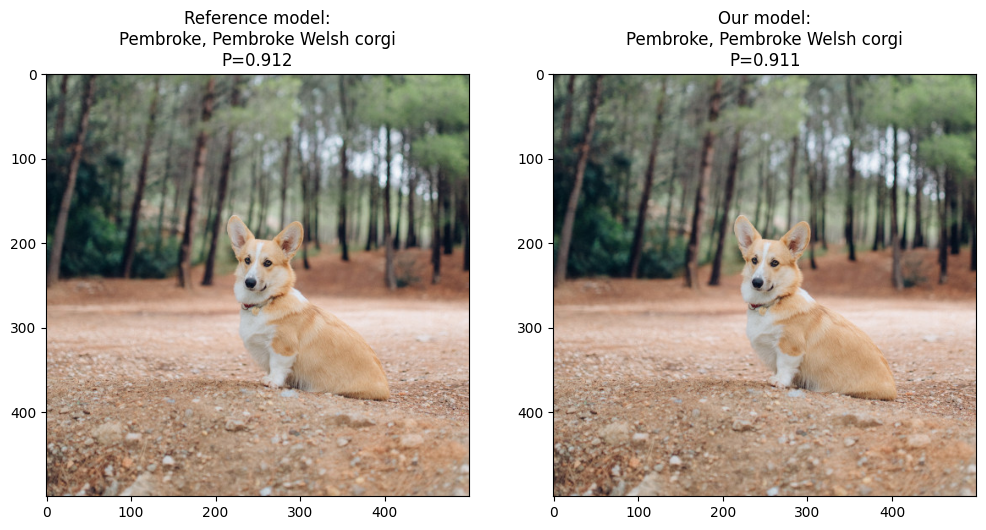

In [5]:
import torch
import matplotlib.pyplot as plt
from transformers import ViTImageProcessor
from PIL import Image
import requests

url = "https://github.com/pytorch/vision/blob/main/gallery/assets/dog1.jpg?raw=true"
image = Image.open(requests.get(url, stream=True).raw)

processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

inputs = processor(images=image, return_tensors="pt")
tf_model.eval()
with torch.no_grad():
    outputs = tf_model(**inputs)
    logits = outputs.logits.cpu().numpy()

model.eval()
with jax.set_mesh(mesh):
    x = jnp.transpose(jnp.asarray(inputs["pixel_values"]), axes=(0, 2, 3, 1))
    # As model is sharded with fsdp it expects the input with batch dim sharded by num of available devices
    x = jnp.concat([x] * jax.device_count(), axis=0)
    output = model(x)
    output = jax.sharding.reshard(output, jax.P())[:1]

# Model predicts one of the 1000 ImageNet classes.
assert jnp.abs(logits[0, :] - output[0, :]).max() < 0.1

ref_class_idx = logits.argmax(-1).item()
pred_class_idx = output.argmax(-1).item()
fig, axs = plt.subplots(1, 2, figsize=(12, 8))
axs[0].set_title(
    f"Reference model:\n{tf_model.config.id2label[ref_class_idx]}\nP={nnx.softmax(logits, axis=-1)[0, ref_class_idx]:.3f}"
)
axs[0].imshow(image)
axs[1].set_title(
    f"Our model:\n{tf_model.config.id2label[pred_class_idx]}\nP={nnx.softmax(output, axis=-1)[0, pred_class_idx]:.3f}"
)
axs[1].imshow(image)

Replace the classifier with a smaller fully-connected layer returning 20 classes instead of 1000:

In [6]:
with jax.set_mesh(mesh):
    model.classifier = nnx.Linear(model.classifier.in_features, 20, rngs=nnx.Rngs(0))

with jax.set_mesh(mesh):
    model.train()
    x = jnp.ones((4, 224, 224, 3), out_sharding=jax.P("fsdp"))
    y = model(x, rngs=nnx.Rngs(1))
    print("Predictions shape: ", jax.typeof(y))

Predictions shape:  float32[4@fsdp,20]


## Food 101 dataset

In this section, we'll prepare the dataset and train the ViT model. The dataset is [Food 101](https://huggingface.co/datasets/ethz/food101), which consists of 101 food categories with 101,000 images.

In our example, each class will have 250 test set images and 750 training set images. The training images won't be cleaned and will contain some amount of noise (on purpose), mostly in the form of intense colors and sometimes wrong labels. All images are rescaled to have a maximum side length of 512 pixels.

Let's download the dataset from [HuggingFace Datasets](https://huggingface.co/docs/datasets/) and select 20 classes to reduce the dataset size and the model training time. We'll use [TorchVision](https://pytorch.org/vision) to transform input images and [`grain`](https://github.com/google/grain/) for efficient data loading.

In [7]:
from datasets import load_dataset

# Select first 20 classes to reduce the dataset size and the training time.
train_size = 20 * 750
val_size = 20 * 250

train_dataset = load_dataset("food101", split=f"train[:{train_size}]")
val_dataset = load_dataset("food101", split=f"validation[:{val_size}]")

# Create labels mapping where we map current labels between 0 and 19.
labels_mapping = {}
index = 0
for i in range(0, len(val_dataset), 250):
    label = val_dataset[i]["label"]
    if label not in labels_mapping:
        labels_mapping[label] = index
        index += 1

inv_labels_mapping = {v: k for k, v in labels_mapping.items()}

print("Training dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Training dataset size: 15000
Validation dataset size: 5000


In [8]:
import matplotlib.pyplot as plt


def display_datapoints(*datapoints, tag="", names_map=None):
    num_samples = len(datapoints)

    fig, axs = plt.subplots(1, num_samples, figsize=(20, 10))
    for i, datapoint in enumerate(datapoints):
        if isinstance(datapoint, dict):
            img, label = datapoint["image"], datapoint["label"]
        else:
            img, label = datapoint

        if hasattr(img, "dtype") and img.dtype in (np.float32, ):
            img = ((img - img.min()) / (img.max() - img.min()) * 255.0).astype(np.uint8)

        label_str = f" ({names_map[label]})" if names_map is not None else ""
        axs[i].set_title(f"{tag}Label: {label}{label_str}")
        axs[i].imshow(img)

Visualize a few samples from the training and test sets:

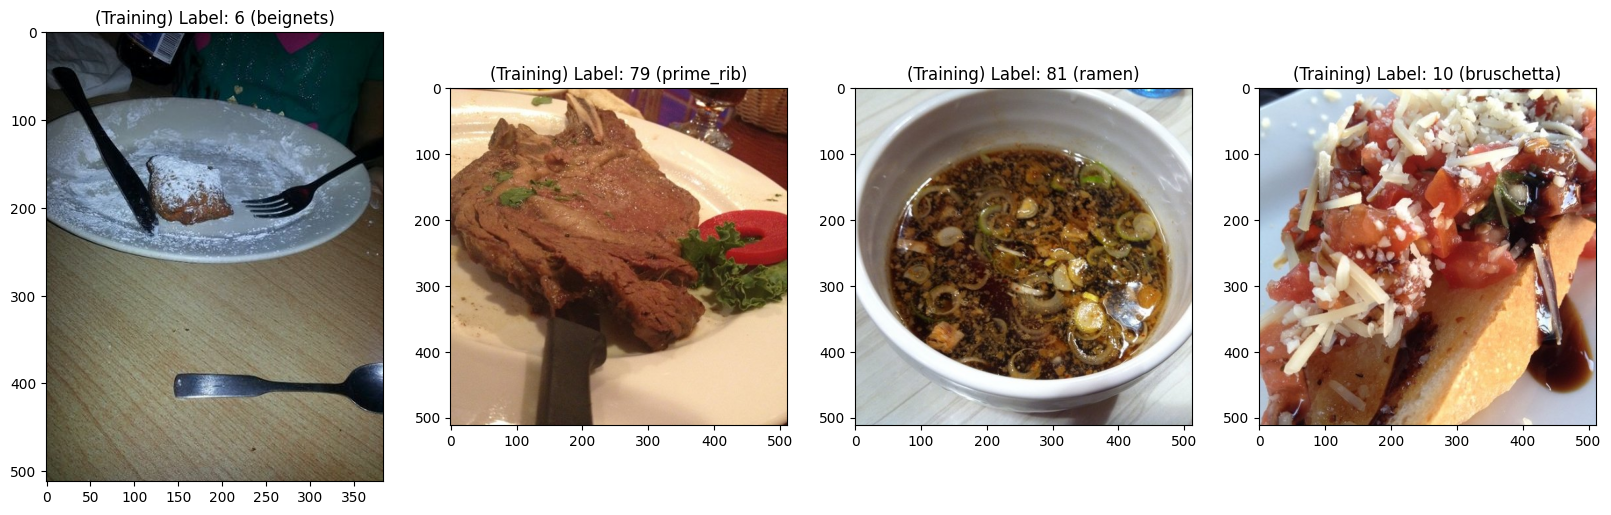

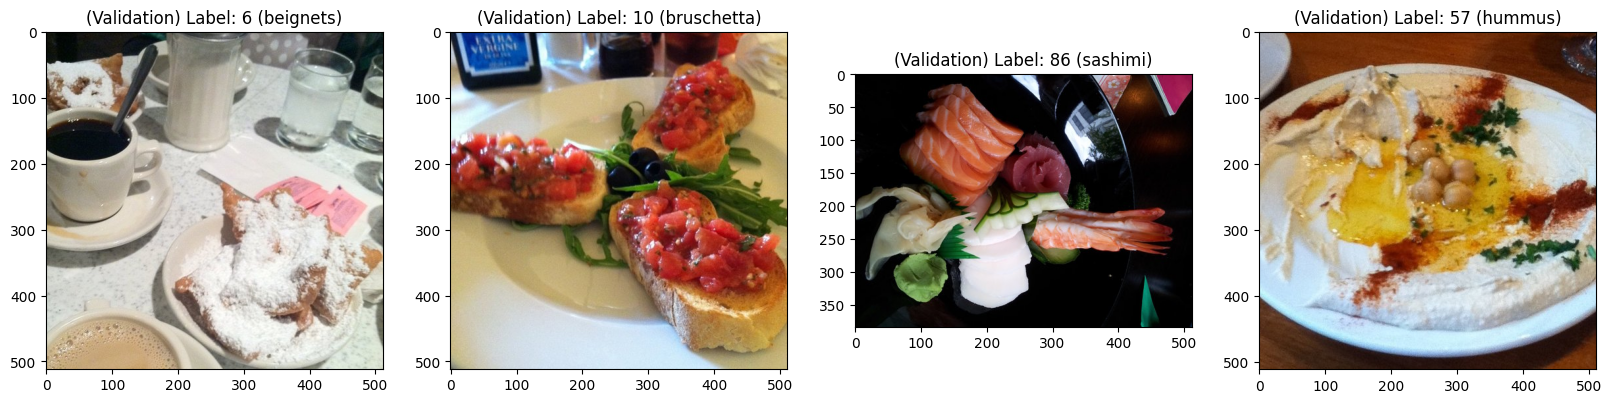

In [9]:
display_datapoints(
    train_dataset[0], train_dataset[1000], train_dataset[2000], train_dataset[3000],
    tag="(Training) ",
    names_map=train_dataset.features["label"].names
)

display_datapoints(
    val_dataset[0], val_dataset[1000], val_dataset[2000], val_dataset[-1],
    tag="(Validation) ",
    names_map=val_dataset.features["label"].names
)

We need to define training and test set image preprocessing helper functions. Training image transformations will also contain random augmentations to prevent overfitting and make the trained model more robust.

In [10]:
import numpy as np
from torchvision.transforms import v2 as T


img_size = 224


def to_np_array(pil_image):
  return np.asarray(pil_image.convert("RGB"))


def normalize(image):
    # Image preprocessing matches the one of pretrained ViT
    mean = np.array([0.5, 0.5, 0.5], dtype=np.float32)
    std = np.array([0.5, 0.5, 0.5], dtype=np.float32)
    image = image.astype(np.float32) / 255.0
    return (image - mean) / std


tv_train_transforms = T.Compose([
    T.RandomResizedCrop((img_size, img_size), scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.2, 0.2, 0.2),
    T.Lambda(to_np_array),
    T.Lambda(normalize),
])


tv_test_transforms = T.Compose([
    T.Resize((img_size, img_size)),
    T.Lambda(to_np_array),
    T.Lambda(normalize),
])


def get_transform(fn):
    def wrapper(batch):
        batch["image"] = [
            fn(pil_image) for pil_image in batch["image"]
        ]
        # map label index between 0 - 19
        batch["label"] = [
            labels_mapping[label] for label in batch["label"]
        ]
        return batch
    return wrapper


train_transforms = get_transform(tv_train_transforms)
val_transforms = get_transform(tv_test_transforms)

train_dataset = train_dataset.with_transform(train_transforms)
val_dataset = val_dataset.with_transform(val_transforms)

In [11]:
import grain.python as grain


seed = 12
train_batch_size = 32
val_batch_size = 2 * train_batch_size


# Create an `grain.IndexSampler` with no sharding for single-device computations.
train_sampler = grain.IndexSampler(
    len(train_dataset),  # The total number of samples in the data source.
    shuffle=True,            # Shuffle the data to randomize the order.of samples
    seed=seed,               # Set a seed for reproducibility.
    shard_options=grain.NoSharding(),  # No multi-host sharding since this is a single host setup.
    num_epochs=1,            # Iterate over the dataset for one epoch.
)

val_sampler = grain.IndexSampler(
    len(val_dataset),  # The total number of samples in the data source.
    shuffle=False,         # Do not shuffle the data.
    seed=seed,             # Set a seed for reproducibility.
    shard_options=grain.NoSharding(),  # No multi-host sharding since this is a single host setup.
    num_epochs=1,          # Iterate over the dataset for one epoch.
)


train_loader = grain.DataLoader(
    data_source=train_dataset,
    sampler=train_sampler,                 # A sampler to determine how to access the data.
    worker_count=4,                        # Number of child processes launched to parallelize the transformations among.
    worker_buffer_size=2,                  # Count of output batches to produce in advance per worker.
    operations=[
        grain.Batch(train_batch_size, drop_remainder=True),
    ]
)

# Test (validation) dataset `grain.DataLoader`.
val_loader = grain.DataLoader(
    data_source=val_dataset,
    sampler=val_sampler,                   # A sampler to determine how to access the data.
    worker_count=4,                        # Number of child processes launched to parallelize the transformations among.
    worker_buffer_size=2,
    operations=[
        grain.Batch(val_batch_size),
    ]
)

Let's visualize the training and test set batches:

In [12]:
train_batch = next(iter(train_loader))
val_batch = next(iter(val_loader))

In [13]:
print("Training batch info:", train_batch["image"].shape, train_batch["image"].dtype, train_batch["label"].shape, train_batch["label"].dtype)
print("Validation batch info:", val_batch["image"].shape, val_batch["image"].dtype, val_batch["label"].shape, val_batch["label"].dtype)

Training batch info: (32, 224, 224, 3) float32 (32,) int64
Validation batch info: (64, 224, 224, 3) float32 (64,) int64


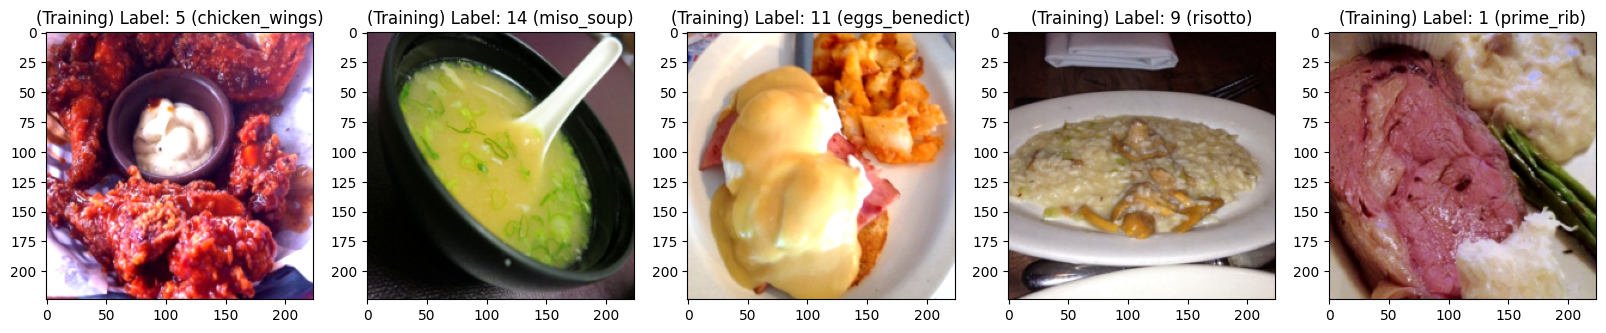

In [14]:
display_datapoints(
    *[(train_batch["image"][i], train_batch["label"][i]) for i in range(5)],
    tag="(Training) ",
    names_map={k: train_dataset.features["label"].names[v] for k, v in inv_labels_mapping.items()}
)

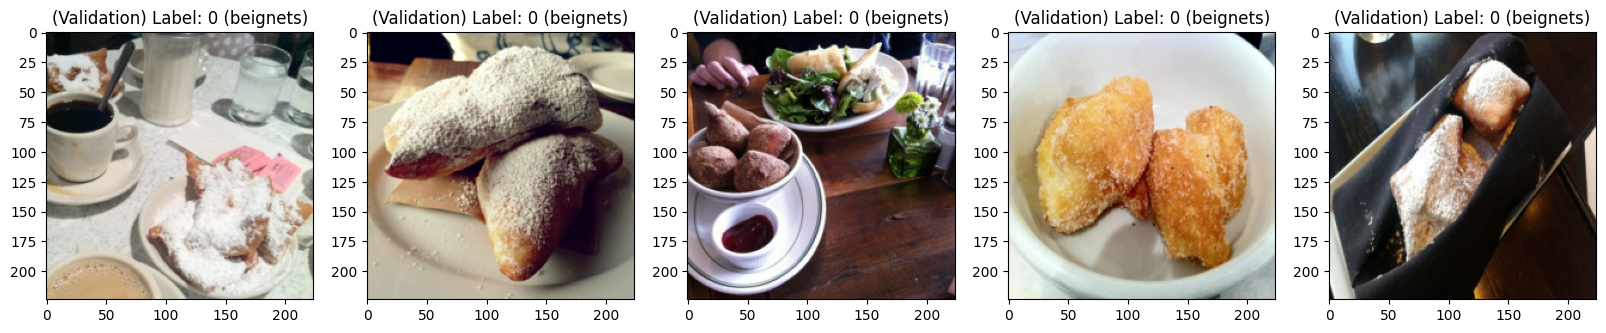

In [15]:
display_datapoints(
    *[(val_batch["image"][i], val_batch["label"][i]) for i in range(5)],
    tag="(Validation) ",
    names_map={k: val_dataset.features["label"].names[v] for k, v in inv_labels_mapping.items()}
)

## Defining the optimizier, the loss function, training/test steps, and metrics

In this section, we'll define the optimizer, the loss function, the training and test step functions, and then begin training the model.

First, initiliaze the learning rate and the SGD optimizer with `optax`, using `optax.sgd` and `flax.nnx.Optimizer`:

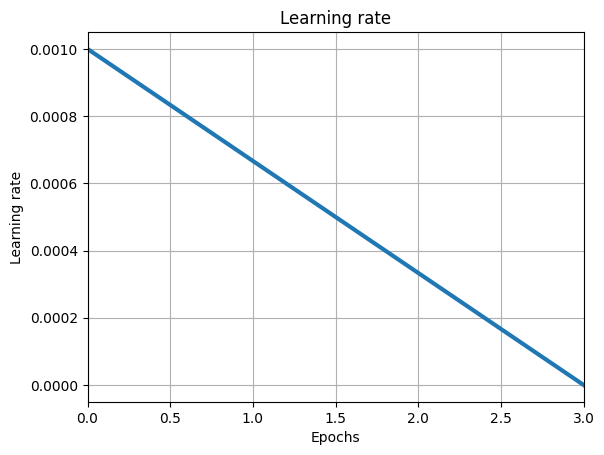

In [16]:
num_epochs = 3
learning_rate = 0.001
momentum = 0.8
total_steps = len(train_dataset) // train_batch_size

lr_schedule = optax.linear_schedule(learning_rate, 0.0, num_epochs * total_steps)

iterate_subsample = np.linspace(0, num_epochs * total_steps, 100)
plt.plot(
    np.linspace(0, num_epochs, len(iterate_subsample)),
    [lr_schedule(i) for i in iterate_subsample],
    lw=3,
)
plt.title("Learning rate")
plt.xlabel("Epochs")
plt.ylabel("Learning rate")
plt.grid()
plt.xlim((0, num_epochs))
plt.show()


with jax.set_mesh(mesh):
    optimizer = nnx.Optimizer(model, optax.sgd(lr_schedule, momentum, nesterov=True), wrt=nnx.Param)

Define a loss function with `optax.softmax_cross_entropy_with_integer_labels`:

In [17]:
def compute_losses_and_logits(
    model: nnx.Module,
    images: jax.Array,
    labels: jax.Array,
    rngs: nnx.Rngs | None = None
) -> tuple[jax.Array, jax.Array]:
    logits = model(images, rngs=rngs)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=labels
    ).mean()
    return loss, logits

Set up the train and test steps (with `nnx.jit` and `nnx.value_and_grad`:

In [18]:
@nnx.jit(donate_argnames=("model", "optimizer"))
def train_step(
    model: nnx.Module, optimizer: nnx.Optimizer, rngs: nnx.Rngs, batch: tuple[jax.Array, jax.Array]
):
    images, labels = batch
    grad_fn = nnx.value_and_grad(compute_losses_and_logits, has_aux=True)
    (loss, _), grads = grad_fn(model, images, labels, rngs.fork())

    optimizer.update(model, grads)

    return loss


@nnx.jit
def eval_step(
    model: nnx.Module, batch: tuple[jax.Array, jax.Array], eval_metrics: nnx.MultiMetric
):
    images, labels = batch
    loss, logits = compute_losses_and_logits(model, images, labels)
    eval_metrics.update(
        loss=loss,
        logits=logits,
        labels=labels,
    )

Instantiae the metrics function with `nnx.MultiMetric`:

In [19]:
eval_metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
    accuracy=nnx.metrics.Accuracy(),
)


train_metrics_history = {
    "train_loss": [],
}

eval_metrics_history = {
    "val_loss": [],
    "val_accuracy": [],
}

In [20]:
import tqdm


bar_format = "{desc}[{n_fmt}/{total_fmt}]{postfix} [{elapsed}<{remaining}]"

# We define a view of the model sharing the weights but with attributes set for evaluation
eval_model = nnx.view(model, deterministic=True)
rngs = nnx.Rngs(12)

def train_one_epoch(epoch):
    with tqdm.tqdm(
        desc=f"[train] epoch: {epoch}/{num_epochs}, ",
        total=total_steps,
        bar_format=bar_format,
        leave=True,
    ) as pbar, jax.set_mesh(mesh):
        prev_loss = None
        for batch in train_loader:

            # Convert np.ndarray to jax.Array on GPUs
            images = jax.device_put(batch["image"], device=jax.P("fsdp"))
            labels = jax.device_put(batch["label"].astype(int), device=jax.P("fsdp"))

            loss = train_step(model, optimizer, rngs, (images, labels))
            if prev_loss is not None:
                # Async metrics recording and printing
                train_metrics_history["train_loss"].append(prev_loss.item())
                pbar.set_postfix({"loss": prev_loss.item()})
            prev_loss = loss
            pbar.update(1)


def evaluate_model(epoch):
    # Computes the metrics on the training and test sets after each training epoch.
    with jax.set_mesh(mesh):
        eval_metrics.reset()  # Reset the eval metrics
        for val_batch in val_loader:

            # Convert np.ndarray to jax.Array on GPUs
            images = jax.device_put(val_batch["image"], device=jax.P("fsdp"))
            labels = jax.device_put(val_batch["label"].astype(int), device=jax.P("fsdp"))

            eval_step(eval_model, (images, labels), eval_metrics)

    for metric, value in eval_metrics.compute().items():
        eval_metrics_history[f'val_{metric}'].append(value)

    print(f"[val] epoch: {epoch + 1}/{num_epochs}")
    print(f"- total loss: {eval_metrics_history['val_loss'][-1]:0.4f}")
    print(f"- Accuracy: {eval_metrics_history['val_accuracy'][-1]:0.4f}")

## Training the model

Begin training the model:

In [21]:
%%time

for epoch in range(num_epochs):
    train_one_epoch(epoch)
    evaluate_model(epoch)

[train] epoch: 0/3, [468/468], loss=0.289 [02:15<00:00]
/tmp/venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


[val] epoch: 1/3
- total loss: 0.2447
- Accuracy: 0.9346


[train] epoch: 1/3, [468/468], loss=0.204 [01:35<00:00] 
/tmp/venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


[val] epoch: 2/3
- total loss: 0.1975
- Accuracy: 0.9448


[train] epoch: 2/3, [468/468], loss=0.258 [01:36<00:00] 
/tmp/venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


[val] epoch: 3/3
- total loss: 0.1851
- Accuracy: 0.9480
CPU times: user 3min 7s, sys: 50.6 s, total: 3min 57s
Wall time: 6min 15s


Visualize the collected metrics:

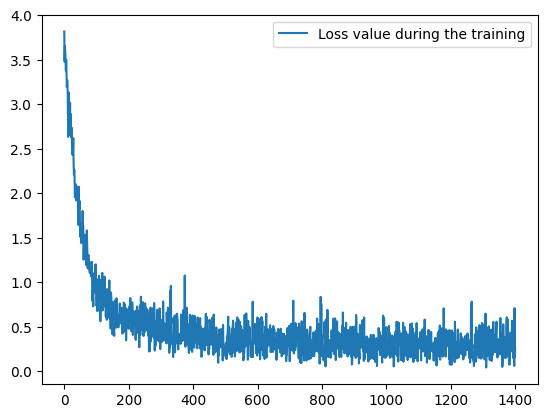

In [22]:
plt.plot(train_metrics_history["train_loss"], label="Loss value during the training")
plt.legend()

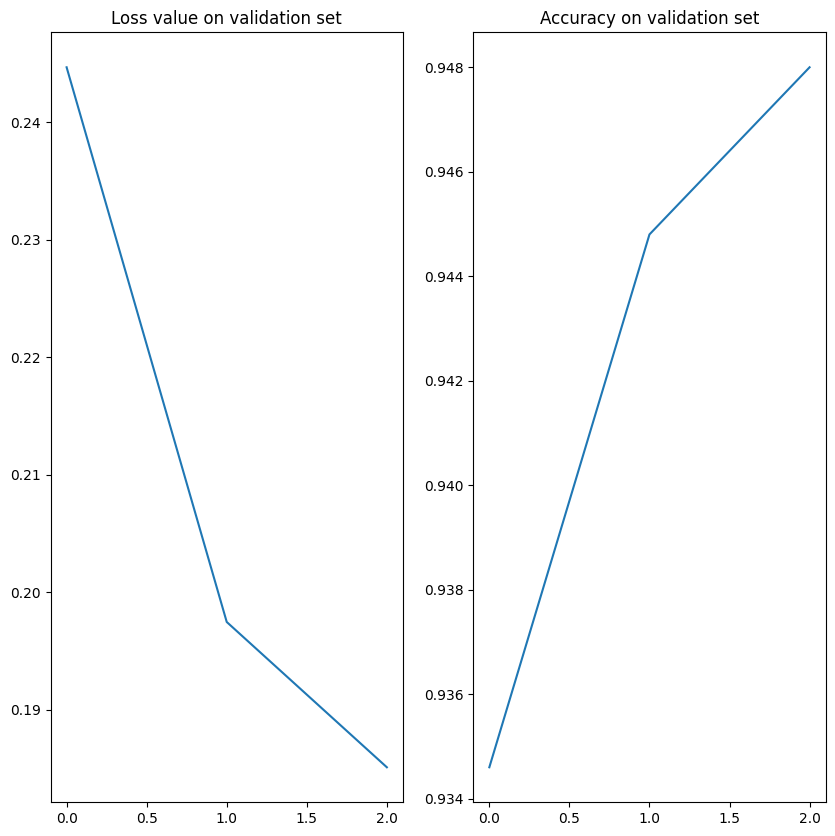

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].set_title("Loss value on validation set")
axs[0].plot(eval_metrics_history["val_loss"])
axs[1].set_title("Accuracy on validation set")
axs[1].plot(eval_metrics_history["val_accuracy"])

Check the model's predictions on the test data:

In [24]:
test_indices = [1, 250, 500, 750, 1000, 1234]

test_images = [val_dataset[i]["image"] for i in test_indices]
expected_labels = [val_dataset[i]["label"] for i in test_indices]

with jax.set_mesh(mesh):
    inputs = jnp.asarray(test_images, out_sharding=jax.P("fsdp"))
    preds = eval_model(inputs)
    preds = jax.sharding.reshard(preds, jax.P())

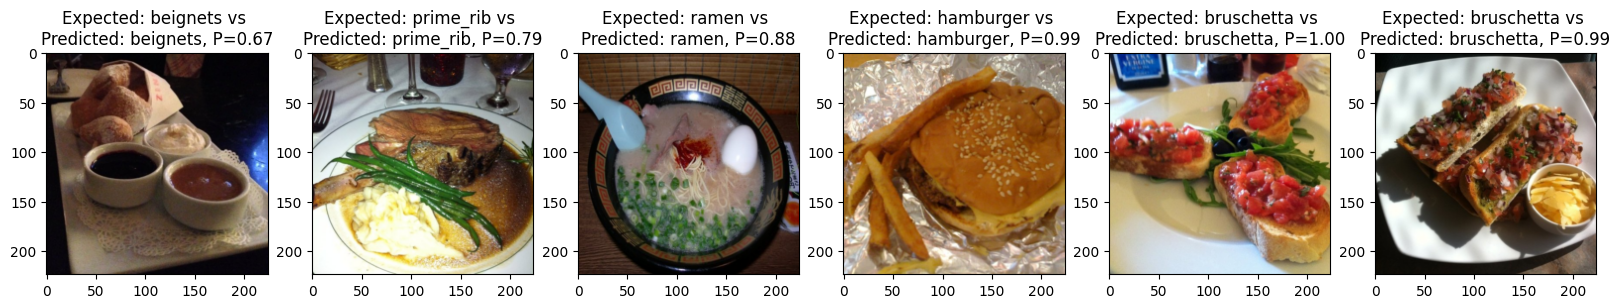

In [25]:
num_samples = len(test_indices)
names_map = train_dataset.features["label"].names

probas = nnx.softmax(preds, axis=1)
pred_labels = probas.argmax(axis=1)


fig, axs = plt.subplots(1, num_samples, figsize=(20, 10))
for i in range(num_samples):
    img, expected_label = test_images[i], expected_labels[i]

    pred_label = pred_labels[i].item()
    proba = probas[i, pred_label].item()
    if img.dtype in (np.float32, ):
        img = ((img - img.min()) / (img.max() - img.min()) * 255.0).astype(np.uint8)

    expected_label_str = names_map[inv_labels_mapping[expected_label]]
    pred_label_str = names_map[inv_labels_mapping[pred_label]]
    axs[i].set_title(f"Expected: {expected_label_str} vs \nPredicted: {pred_label_str}, P={proba:.2f}")
    axs[i].imshow(img)

## Further reading

In this example we implemented the ViT model and finetuned it on a subset of the Food 101 dataset.

For further reading, check out other Examples.